In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv("HR_Analytics.csv")

In [7]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
print('Unique values: ', df['MaritalStatus'].unique())
print('Unique values in Business Travel: ', df['BusinessTravel'].unique())
print('Unique values in Education Field: ', df['EducationField'].unique())
print('Unique values in Department: ', df['Department'].unique())

Unique values:  ['Single' 'Married' 'Divorced']
Unique values in Business Travel:  ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Unique values in Education Field:  ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Unique values in Department:  ['Sales' 'Research & Development' 'Human Resources']


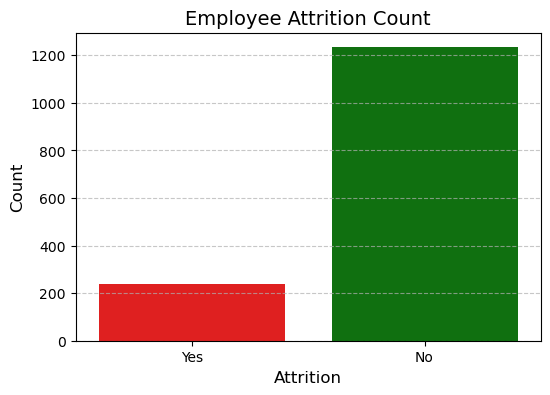

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette=['red','green'])
plt.title('Employee Attrition Count', fontsize=14)
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

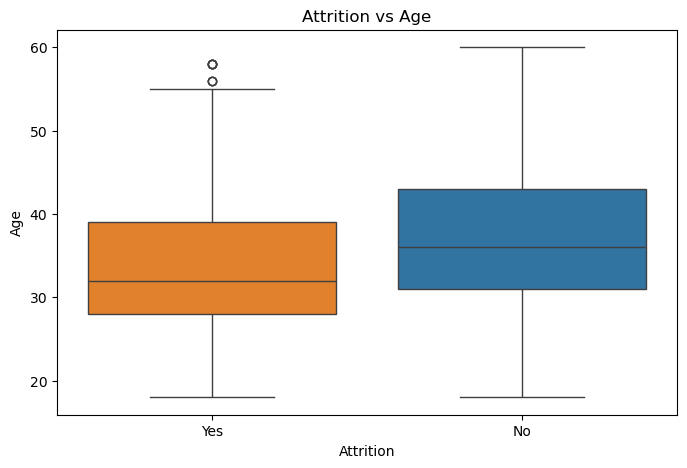

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='Age', palette={'No': '#1f77b4', 'Yes': '#ff7f0e'})
plt.title('Attrition vs Age')
plt.show()

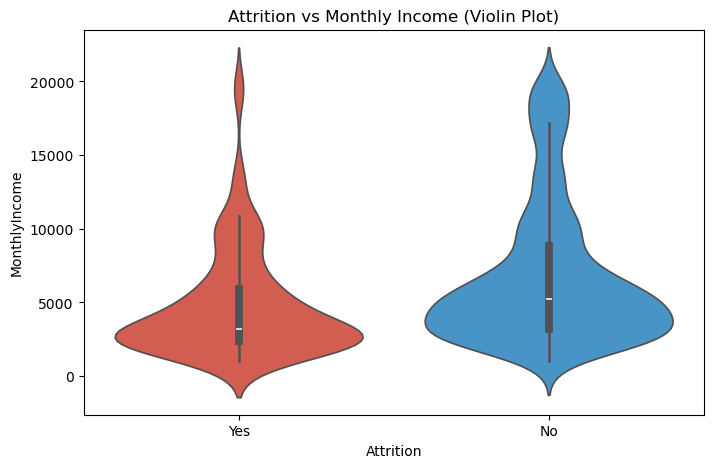

In [12]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Attrition', y='MonthlyIncome', palette=['#E74C3C', '#3498DB'])
plt.title('Attrition vs Monthly Income (Violin Plot)')
plt.show()


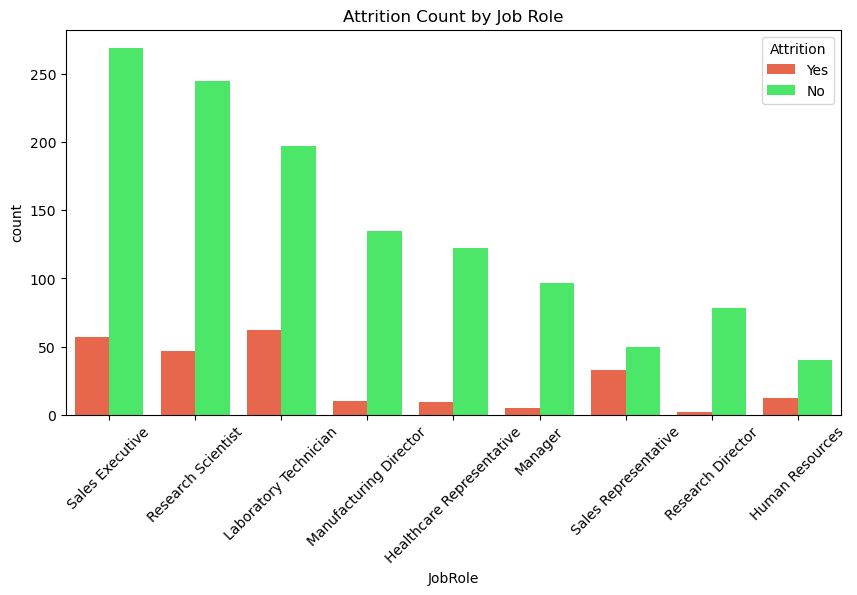

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='JobRole', hue='Attrition', palette=['#FF5733', '#33FF57'])
plt.xticks(rotation=45)
plt.title('Attrition Count by Job Role')
plt.show()


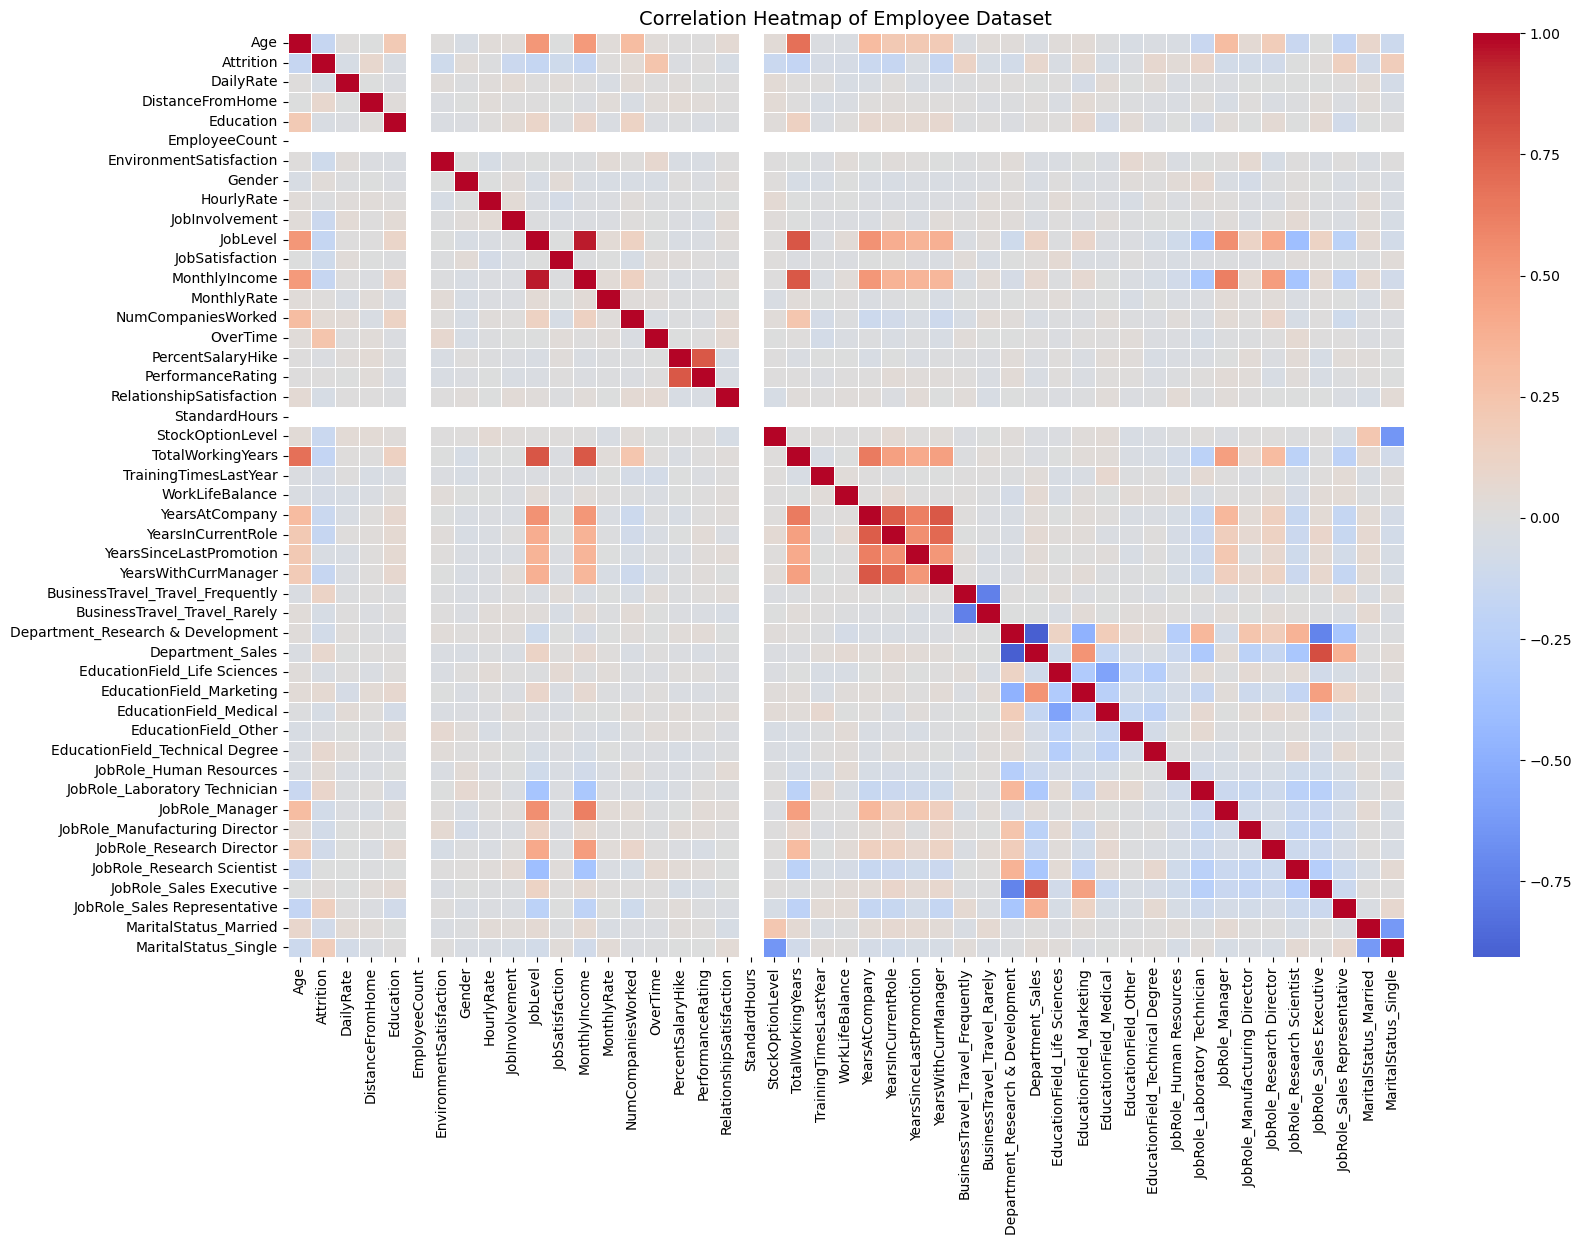

In [14]:
# Convert binary categorical columns to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Drop irrelevant columns (if needed)
df.drop(columns=['EmployeeNumber', 'Over18'], inplace=True)

# One-hot encode categorical columns
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Compute correlation matrix
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5, center=0)

# Title
plt.title('Correlation Heatmap of Employee Dataset', fontsize=14)

# Show plot
plt.show()

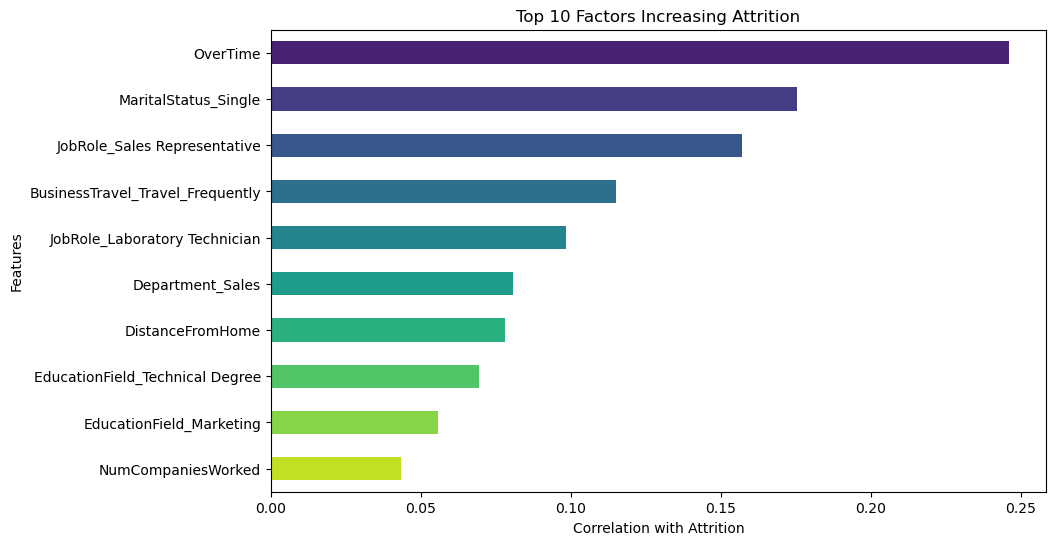

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get correlation of all columns with Attrition
attrition_corr = df.corr()['Attrition'].drop('Attrition')

# Select top 10 most positively correlated features (increasing attrition)
top_positive_features = attrition_corr.sort_values(ascending=False).head(10)

# Generate different colors using a colormap
colours = sns.color_palette("viridis", len(top_positive_features))

# Bar Plot
plt.figure(figsize=(10, 6))
top_positive_features.plot(kind='barh', color=colours)  # Corrected 'color'
plt.xlabel('Correlation with Attrition')
plt.ylabel('Features')
plt.title('Top 10 Factors Increasing Attrition')
plt.gca().invert_yaxis()  # Highest at the top
plt.show()


In [16]:
df.drop(columns=['EmployeeCount'], inplace=True)

In [17]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
def prepare_dataset(df, drop_columns=['Attrition','StandardHours']):
    X = df.drop(columns=drop_columns)
    y = df['Attrition']
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, scale=False):
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n {model.__class__.__name__} Performance:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    acc = accuracy_score(y_test, y_pred)
    print(f" {model.__class__.__name__} Accuracy: {acc:.4f}")
    return acc

In [24]:
X_train, X_test, y_train, y_test = prepare_dataset(df)

In [25]:
# Logistic Regression
logistic_model = LogisticRegression(random_state=42)
train_and_evaluate(logistic_model, X_train, X_test, y_train, y_test, scale=True)


📌 LogisticRegression Performance:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Confusion Matrix:
 [[237  10]
 [ 31  16]]
✅ LogisticRegression Accuracy: 0.8605


0.8605442176870748

In [26]:
# Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
train_and_evaluate(random_forest_model, X_train, X_test, y_train, y_test, scale=False)


📌 RandomForestClassifier Performance:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.30      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.57      0.52      0.50       294
weighted avg       0.76      0.83      0.78       294

Confusion Matrix:
 [[240   7]
 [ 44   3]]
✅ RandomForestClassifier Accuracy: 0.8265


0.826530612244898

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define hyperparameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search CV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

# Best Model and Evaluation
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print(" Best Parameters:", grid_search.best_params_)
print("\n Performance After Tuning:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"\n Accuracy: {accuracy_score(y_test, y_pred):.4f}")


✅ Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📌 Performance After Tuning:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294

Confusion Matrix:
 [[239   8]
 [ 41   6]]

✅ Accuracy: 0.8333


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import loguniform

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameters
param_dist = {
    'C': loguniform(0.001, 10),
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500]
}

# Randomized Search CV
log_reg = LogisticRegression(random_state=42)
random_search = RandomizedSearchCV(
    log_reg, param_distributions=param_dist, n_iter=10, 
    cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)

# Train
random_search.fit(X_train_scaled, y_train)

# Best Model and Evaluation
best_log_reg = random_search.best_estimator_
y_pred = best_log_reg.predict(X_test_scaled)

print(" Best Parameters:", random_search.best_params_)
print("\n📌 Performance After Tuning:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"\n Accuracy: {accuracy_score(y_test, y_pred):.4f}")


✅ Best Parameters: {'C': 0.8471801418819978, 'max_iter': 100, 'solver': 'lbfgs'}

📌 Performance After Tuning:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Confusion Matrix:
 [[237  10]
 [ 31  16]]

✅ Accuracy: 0.8605


In [33]:
X = df.drop(columns=['Attrition'])  
y = df['Attrition']  

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3101)

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    # Dense(16, activation = 'relu'),
    Dense(1, activation='sigmoid')  
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test))
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6893 - loss: 0.5667 - val_accuracy: 0.8537 - val_loss: 0.3676
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8499 - loss: 0.3684 - val_accuracy: 0.8776 - val_loss: 0.3248
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8732 - loss: 0.3096 - val_accuracy: 0.8776 - val_loss: 0.3062
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9012 - loss: 0.2736 - val_accuracy: 0.8810 - val_loss: 0.3088
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9077 - loss: 0.2403 - val_accuracy: 0.8810 - val_loss: 0.2984
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9066 - loss: 0.2395 - val_accuracy: 0.8810 - val_loss: 0.3081
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9258 - loss: 0.2153 - val_accuracy: 0.8844 - val_loss: 0.3116
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9366 - loss: 0.1818 - val_accuracy: 0.

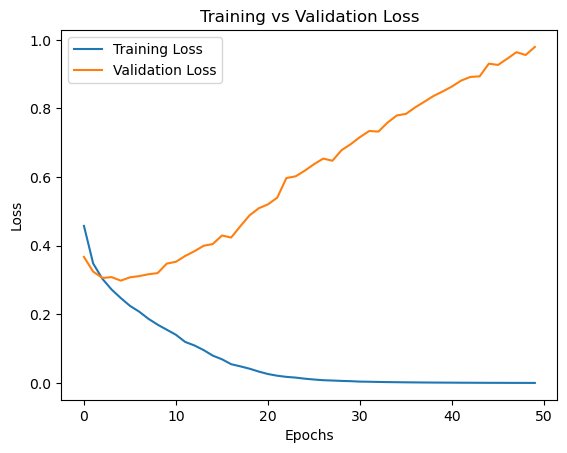

In [37]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [38]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
for i in range(10): 
    print(f"Actual: {y_test.iloc[i]}, Predicted: {y_pred[i][0]}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0


In [39]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_fscore_support, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

In [40]:
model = SVC(C=2)
model.fit(X_train, y_train.values.ravel())
preds = model.predict(X_test)

In [41]:
 def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp, average='binary')
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

evaluate_metrics(y_test, preds)

{'accuracy': 0.8639455782312925,
 'recall': 0.32,
 'precision': 0.7272727272727273,
 'f1score': 0.4444444444444444}

In [42]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [2, 3, 4, 5.6],
    'gamma': ['scale', 'auto', 0.1, 1.0],
    'coef0': [0.0, 0.1, 0.5, 1.0,2.0],
    'shrinking': [True, False],
    'tol': [1e-3, 1e-4, 1e-5],
    'max_iter': [-1, 1000, 5000]
}

In [43]:
svm_grid_search = GridSearchCV(SVC(), param_grid, cv=5)
svm_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'coef0': [0.0, 0.1, 0.5, 1.0, 2.0],
                         'degree': [2, 3, 4, 5.6],
                         'gamma': ['scale', 'auto', 0.1, 1.0],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
                         'max_iter': [-1, 1000, 5000],
                         'shrinking': [True, False],
                         'tol': [0.001, 0.0001, 1e-05]})

In [44]:
print("\nSVM - Best Parameters:", svm_grid_search.best_params_)
print("SVM - Best Score:", svm_grid_search.best_score_)


SVM - Best Parameters: {'C': 0.1, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'shrinking': True, 'tol': 0.0001}
SVM - Best Score: 0.8690443562928237


In [45]:
svm_best_model = svm_grid_search.best_estimator_ #best model
y_pred_svm = svm_best_model.predict(X_test)
print("SVM - Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print(f"SVM: {accuracy_score(y_test, y_pred_svm)}")

SVM - Test Accuracy: 0.8945578231292517
SVM: 0.8945578231292517


In [46]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=3515)

# Fit the training data
model2.fit(X_train, y_train)

DecisionTreeClassifier(random_state=3515)

In [47]:
y_pred_dt = model2.predict(X_test)

In [48]:
evaluate_metrics(y_test, y_pred_dt)

{'accuracy': 0.8129251700680272,
 'recall': 0.4,
 'precision': 0.4444444444444444,
 'f1score': 0.42105263157894735}

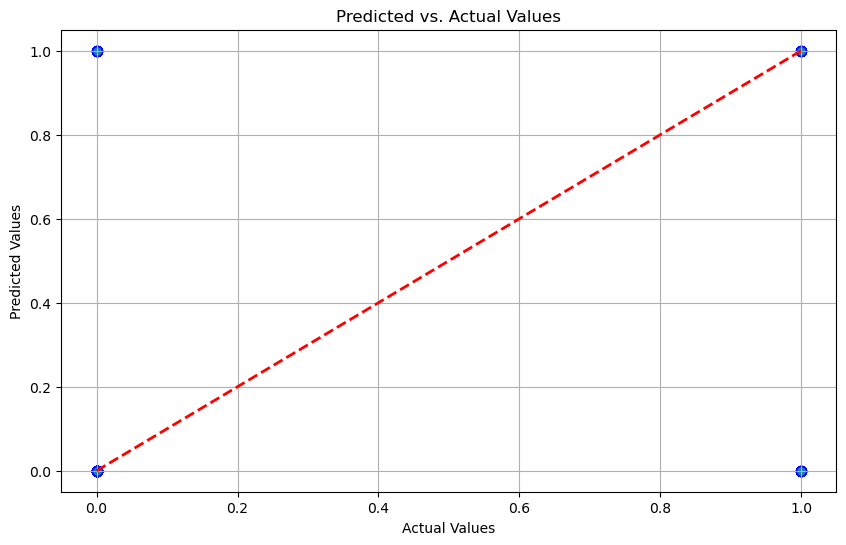

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.7, edgecolors='b', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Values')
plt.grid(True)
plt.show()

In [50]:
dt_param_grid = {
    'max_depth': [1,3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [51]:
dt_grid_search = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
dt_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 3, 5, 10],
                         'min_samples_split': [2, 5, 10]})

In [52]:
print("Decision Tree - Best Parameters:", dt_grid_search.best_params_)
print("Decision Tree - Best Score:", dt_grid_search.best_score_)

Decision Tree - Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Decision Tree - Best Score: 0.8409989181391995


In [53]:
dt_best_model = dt_grid_search.best_estimator_

In [54]:
y_pred_dt = dt_best_model.predict(X_test)

In [55]:
print("\nDecision Tree - Test Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree - Test Accuracy: 0.8367346938775511


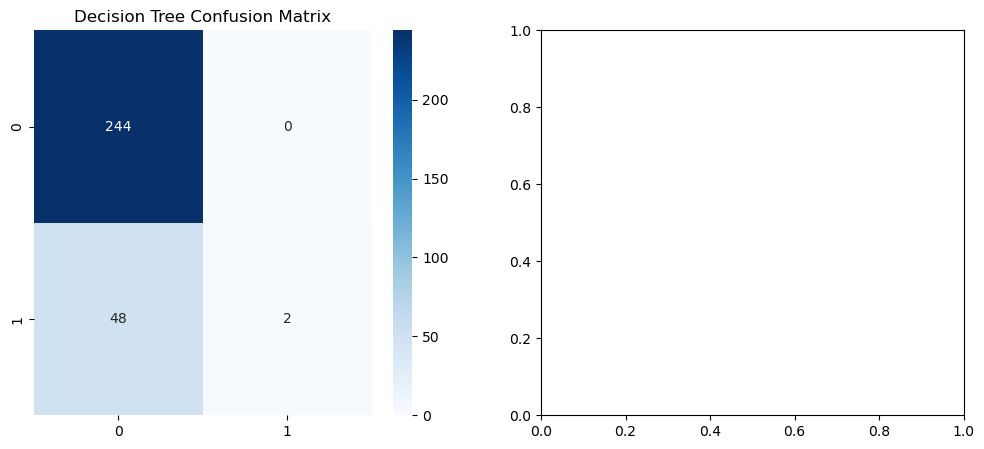

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Decision Tree Confusion Matrix')
plt.show()

In [57]:
from xgboost import XGBClassifier

In [58]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Accuracy: 0.8810


In [59]:
xgb_conf_matrix = confusion_matrix(y_test, xgb_preds)
xgb_class_report = classification_report(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)

In [60]:
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print("Confusion Matrix:\n", xgb_conf_matrix)
print("Classification Report:\n", xgb_class_report)
print(f"F1 Score: {xgb_f1:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")

XGBoost Accuracy: 0.8810
Confusion Matrix:
 [[240   4]
 [ 31  19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       244
           1       0.83      0.38      0.52        50

    accuracy                           0.88       294
   macro avg       0.86      0.68      0.73       294
weighted avg       0.88      0.88      0.86       294

F1 Score: 0.5205
Precision: 0.8261
Recall: 0.3800


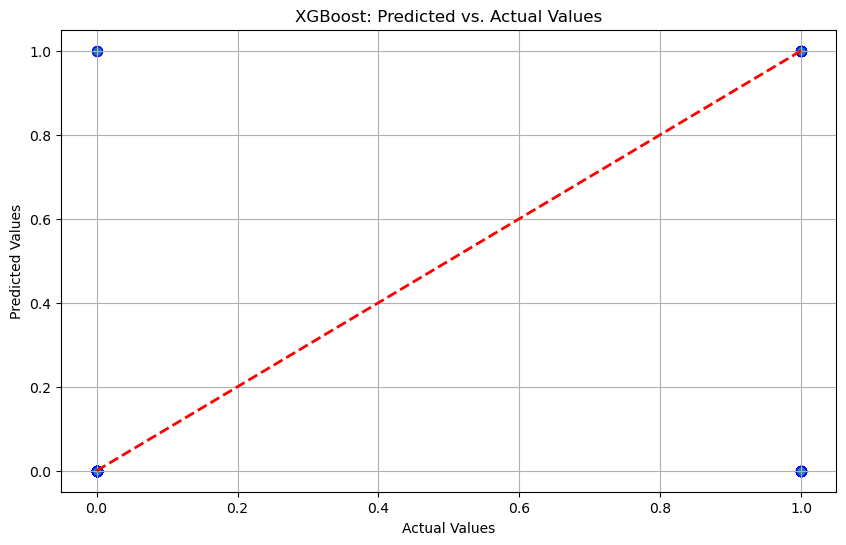

In [61]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, xgb_preds, alpha=0.7, edgecolors='b', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost: Predicted vs. Actual Values')
plt.grid(True)
plt.show()

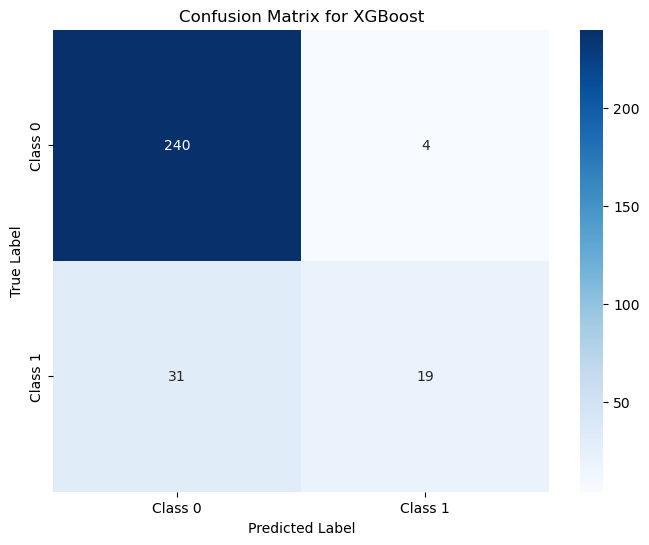

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost')
plt.show()